# E17e Fourier Analysis of Coupled Electric Oscillations
## Yaman Ajaj (3722952);  Guilherme Schewtschik (3748052)

### Theoretical Background:
In this experiment, we investigate coupled electrical oscillations in LC-circuits using both capacitive and inductive coupling. The key theoretical concepts and governing equations are summarized below:
1. **Uncoupled Resonant Circuit** A single LC-resonator of inductance $L$ and capacitance $C$ exhibits free (undriven) oscillations whose angular frequency is:
    $$\omega_0 = \frac{1}{\sqrt{LC}} \rightarrow f_0 = \frac{\omega_0}{2\pi}$$
   These arise from the balance of inductive and capacitive voltages under negligible damping
2. **Capacitive Coupling** Two identical LC-circuits coupled via a capacitor $C_K$ can be arranged in two configurations:
    - **Low-point circuit**: The equations of motion for currents $I_A$, $I_B$ in each loop are
      $$\frac{d^2 I_A}{dt^2} + \frac{1}{LC} I_A + \frac{1}{LC_K} (I_A - I_B) = 0$$
      $$\frac{d^2 I_B}{dt^2} + \frac{1}{LC} I_B + \frac{1}{LC_K} (I_B - I_A) = 0$$
    By forming $I_+ = I_A + I_B$ and $I_- = I_A - I_B$, one finds two eigenmodes:

- **In-phase** ($I_- = 0$) at frequency:
  $$\omega_{1} = \omega_0 = \sqrt{\frac{1}{LC}}$$
- **Out-of-phase** ($I_+ = 0$) at frequency:
  $$\omega_{2} = \frac{1}{\sqrt{L(C^{-1}+ 2C_K^{-1})^{-1}}}$$
  The capacitive coupling factor follows $$k_{C,T} = \frac{C}{C + C_K}$$
- **High-point circuit** Charging the two capacitors either in-phase ($U_a=U_b$) or anti-phase ($U_a=−U_b$) excites the in- and out-of-phase modes directly. One obtains:
      $$\omega_{-} = \sqrt{\frac{1}{LC}}$$
      $$\omega_{+} = \frac{1}{\sqrt{L(C+ 2C_K)}} \rightarrow k_{C,H} = \frac{C_K}{C + C_k}$$

3. **Beat Oscillations**
  If only one circuit is excited ($I_A(0) \neq 0, I_B = 0$), the superposition of the two modes leads to beats. The beat angular frequency is:
  $$\omega_S = \omega_2 - \omega_1 \rightarrow T_S = \frac{2\pi}{\omega_S}$$

4. **Inductive Coupling** Two identical LC-circuits coupled by mutual inductance $M$ obey
  $$\frac{d^2 I_A}{dt^2}L + M \frac{d^2 I_B}{dt^2} + \frac{1}{C} I_A = 0$$
  $$\frac{d^2 I_B}{dt^2}L + M \frac{d^2 I_A}{dt^2} + \frac{1}{C} I_B = 0$$
Defining $k_L = \frac{M}{L}$, the eigenfunctions are:
  $$\omega_{\pm} = \frac{\omega_0}{\sqrt{1 \pm k_L}}$$
  and for weak coupling $\Delta \omega = \omega_- - \omega_+ \approx k_L \omega_0$.

## Experimental Setup and Analysis:
The experiment employs a USB-oscilloscope with FFT capability (PicoScope 2000/5000 series), variable capacitors, coils, resistors, and switches mounted on a circuit board. All measurements are recorded digitally and transferred to a PC for analysis

1. **Low-Point Capacitive Coupling**
    - Assemble the circuit as shown in the figure: two series LC branches in parallel with a variable $C_K$.
    - Charge capacitors via the DC source $U_a$, then close the switch to initiate free oscillations.
    - Record time-domain traces and use the FFT function to obtain frequency spectra
    - Repeat for ten values of $C_K$, exporting all ten spectra for a combined plot.

The valued obtained for k given diferent Ck's is:
k = 0.90 for Ck = 22.22µF
k = 0.80 for Ck = 55.55µF
k = 0.77 for Ck = 66.66µF
k = 0.70 for Ck = 99.99µF
k = 0.68 for Ck = 111.10µF
k = 0.61 for Ck = 166.65µF
k = 0.53 for Ck = 222.20µF
k = 0.46 for Ck = 277.75µF
k = 0.35 for Ck = 444.40µF
k = 0.00 for Ck = 555.50µF
The valued obtained for C given diferent Ck's is:
C = 194.90µF for Ck = 22.22µF
C = 222.20µF for Ck = 55.55µF
C = 227.22µF for Ck = 66.66µF
C = 235.05µF for Ck = 99.99µF
C = 234.67µF for Ck = 111.10µF
C = 256.81µF for Ck = 166.65µF
C = 246.94µF for Ck = 222.20µF
C = 240.62µF for Ck = 277.75µF
C = 244.32µF for Ck = 444.40µF
C = 0.00µF for Ck = 555.50µF


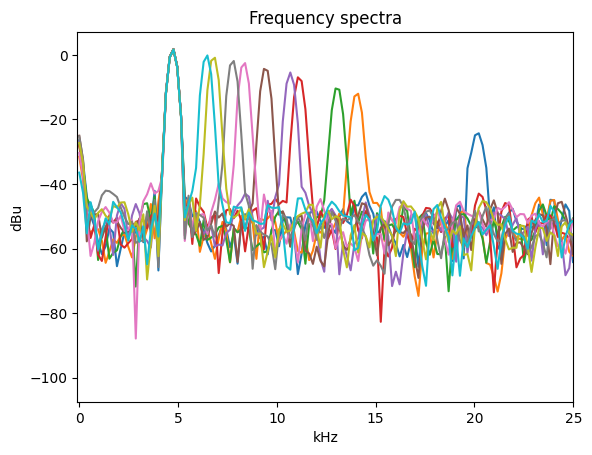

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit 

#Values for Ck
Ck = np.array([0.002,0.005,0.006,0.009,0.010,0.015,0.020,0.025,0.04,0.05])
Ck = 1.111e-2*Ck

#Data import
A_list = []
for i in range(1,11):
    data1 = pd.read_csv(f'Data/Task1/Task1_freq_{i}.csv', sep=',')
    freq = data1['Frequency'].to_numpy()
    y = data1['Channel A'].to_numpy()
    A_list.append(y)
A = np.vstack(A_list)

#Filtering the in and out frequencies
rfreq = []
for i in range(0,10):
    x = A[i]>-40
    f = freq[x]
    split = np.where(np.diff(f)>1)[0]
    segments = np.split(f, split+1)
    for j in range(0,len(segments)):
        a = np.mean(segments[j])
        rfreq.append(a)

#in the last measurament the in and out frequencies where so close it couldnt be differentiated by a simple filter
rfreq.append(rfreq[-1])

rfreq = np.reshape(rfreq,(int(len(rfreq)/3),3))

f_in = rfreq[:,1]
f_out = rfreq[:,2]

#calculations
k = (f_out**2-f_in**2)/(f_out**2+f_in**2)
C = k*Ck/(1-k)

#results for k
print("The valued obtained for k given diferent Ck's is:")
for i in range(0,len(C)):
    print(f'k = {"%.2f"%(k[i])} for Ck = {"%.2f"%(Ck[i]*1e6)}µF')

#results for C
print("The valued obtained for C given diferent Ck's is:")
for i in range(0,len(C)):
    print(f'C = {"%.2f"%(C[i]*1e6)}µF for Ck = {"%.2f"%(Ck[i]*1e6)}µF')

#plot
plt.figure(1)
for i in range(0,10):
    plt.title('Frequency spectra')
    plt.xlabel('kHz')
    plt.ylabel('dBu')
    plt.xlim(-0.1,25)
    plt.plot(freq, A[i])

plt.show()

2. **High-Point Capacitive Coupling**
    - Build the high-point circuit as shown in the figure with separate charging switches $S_a$, $S_b$.
    - For in-phase mode: set $U_a=U_b$; for out-of-phase: $U_a=−U_b$.
    - Measure and record frequency spectra for ten values of $C_K$.

The valued obtained for k given diferent Ck's is:
k = 0.00 for Ck = 22.22µF
k = -0.00 for Ck = 55.55µF
k = 0.34 for Ck = 111.10µF
k = 0.42 for Ck = 166.65µF
k = 0.50 for Ck = 222.20µF
k = 0.55 for Ck = 277.75µF
k = 0.60 for Ck = 333.30µF
k = 0.63 for Ck = 388.85µF
k = 0.65 for Ck = 444.40µF
k = 0.68 for Ck = 499.95µF
The valued obtained for C given diferent Ck's is:
C = 2696788.26µF for Ck = 22.22µF
C = -581202.19µF for Ck = 55.55µF
C = 213.49µF for Ck = 111.10µF
C = 231.23µF for Ck = 166.65µF
C = 225.28µF for Ck = 222.20µF
C = 228.66µF for Ck = 277.75µF
C = 222.20µF for Ck = 333.30µF
C = 232.82µF for Ck = 388.85µF
C = 238.55µF for Ck = 444.40µF
C = 240.06µF for Ck = 499.95µF


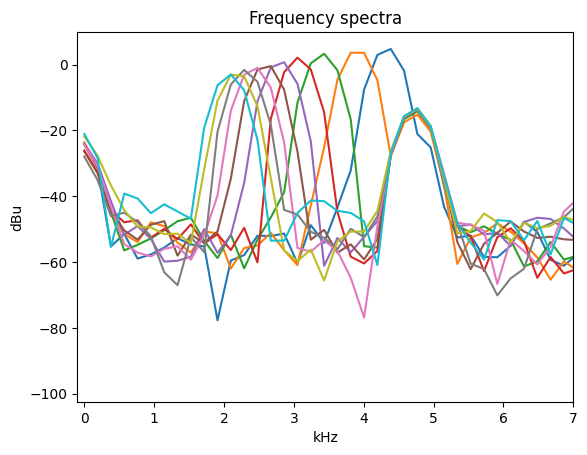

In [ ]:
#Ck values
Ck = np.array([0.002,0.005,0.01,0.015,0.02,0.025,0.03,0.035,0.04,0.045])

Ck = 1.111e-2*Ck

#data import
A_list = []
for i in range(1,11):
    data1 = pd.read_csv(f'Data/Task2/Task2_freq_{i}.csv', sep=',')
    freq = data1['Frequency'].to_numpy()
    y = data1['Channel A'].to_numpy()
    A_list.append(y)
A = np.vstack(A_list)

#filtering out other frequencies
rfreq = []
for i in range(0,10):
    x = A[i]>-40
    f = freq[x]
    split = np.where(np.diff(f)>0.5)[0]
    segments = np.split(f, split+1)
    for j in range(0,len(segments)):
        a = np.mean(segments[j])
        rfreq.append(a)

#adding noise to the frequencies that where too close together to differentiate
rfreq = np.insert(rfreq, 2, rfreq[1]+np.random.rand()*1e-3)
rfreq = np.insert(rfreq, 4, rfreq[4]+np.random.rand()*1e-3)

rfreq = np.reshape(rfreq,(int(len(rfreq)/3),3))

#Calculating k and C
f_in = rfreq[:,1]
f_out = rfreq[:,2]

k = (f_out**2-f_in**2)/(f_out**2+f_in**2)

C = (1-k)*Ck/k

#results for k
print("The valued obtained for k given diferent Ck's is:")
for i in range(0,len(C)):
    print(f'k = {"%.2f"%(k[i])} for Ck = {"%.2f"%(Ck[i]*1e6)}µF')

#results for C
print("The valued obtained for C given diferent Ck's is:")
for i in range(0,len(C)):
    print(f'C = {"%.2f"%(C[i]*1e6)}µF for Ck = {"%.2f"%(Ck[i]*1e6)}µF')

#plotting
plt.figure(1)
for i in range(0,10):
    plt.title('Frequency spectra')
    plt.xlabel('kHz')
    plt.ylabel('dBu')
    plt.xlim(-0.1,7)
    plt.plot(freq, A[i])

plt.show()

3. **Beat Measurements**
    - In the high-point circuit, short one branch, charge the other, then close the switch.
    - Acquire both time-trace and spectrum of the beat oscillation.

The period of the beating is: 8.24 ms


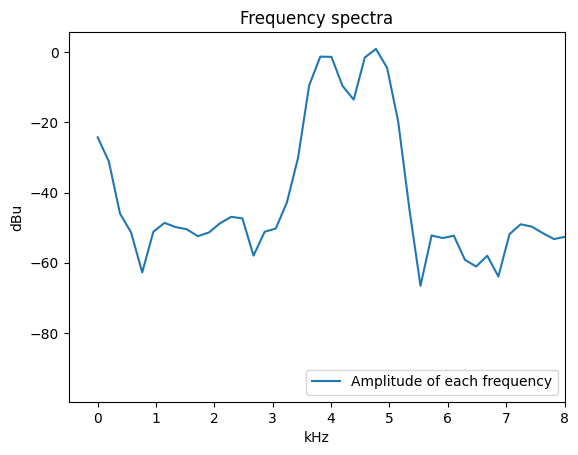

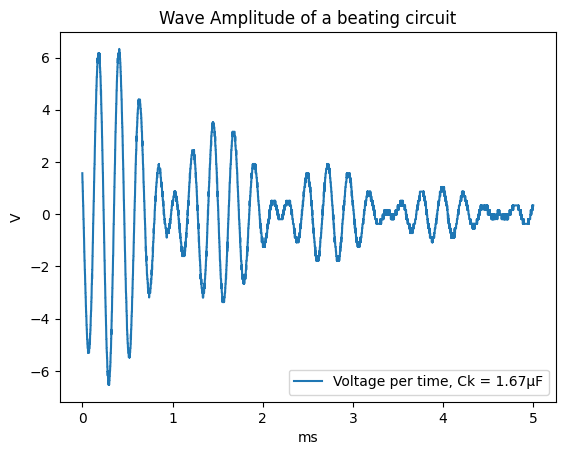

In [ ]:
#data import
data1 = pd.read_csv('Data/Task3/Task3_freq_1.csv', sep=',')
freq = data1['Frequency'].to_numpy()
Af = data1['Channel A'].to_numpy()

data1 = pd.read_csv('Data/Task3/Task3_A_1.csv', sep=',')

#filtering other frequencies
x = Af > -2
rfrec = freq[x]

#taking the mean values of the peeks
f1 = (rfrec[0]+rfrec[1])/2
f2 = (rfrec[2]+rfrec[3])/2

#calculating the period
T = 2*np.pi/(f2-f1)

#result for T
print(f'The period of the beating is: {"%.2f"%T} ms')

#plotting
plt.figure(1)
plt.xlim(-0.5,8)
plt.title('Frequency spectra')
plt.xlabel('kHz')
plt.ylabel('dBu')
plt.plot(freq,Af, label='Amplitude of each frequency')
plt.legend(loc = 'lower right')

plt.figure(2)
plt.title('Wave Amplitude of a beating circuit')
plt.xlabel('ms')
plt.ylabel('V')
plt.plot(data1['Time'], data1['Channel A'], label=f'Voltage per time, Ck = {"%.2f"%(0.015*1.111e2)}µF')
plt.legend(loc='lower right')
plt.show()

4. **Inductive Coupling**
    - Use two identical flat coils facing each other.
    - ary the coil separation $d$ over eight positions.
    - For each $d$, measure uncoupled $f_0$ and coupled $f_{\pm}$ to compute $M$ and $K_L$.

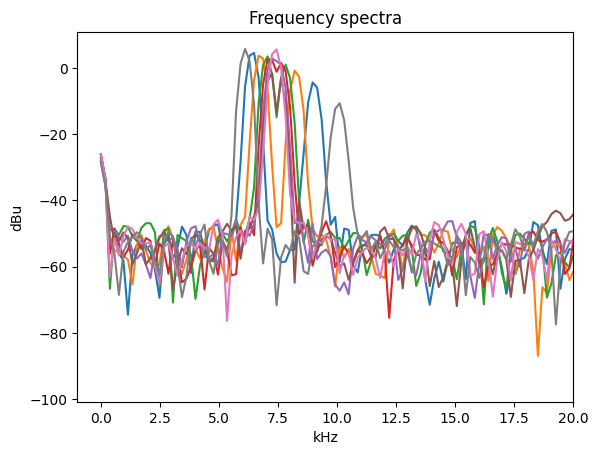

In [19]:
A_list = []

for i in range(1,9):
    data1 = pd.read_csv(f'Data/Task4/Task4_freq_{i}.csv', sep=',')
    freq = data1['Frequency'].to_numpy()
    y = data1['Channel A'].to_numpy()
    A_list.append(y)

A = np.vstack(A_list)

for i in range(0,8):
    plt.title('Frequency spectra')
    plt.xlabel('kHz')
    plt.ylabel('dBu')
    plt.xlim(-1,20)
    plt.plot(freq, A[i])

All instrument settings (time base, trigger level, FFT parameters) are optimized to resolve both $f_1$ and $f_2$ clearly. Data are logged systematically for subsequent plotting and fitting.